# Model Comaprison

Processing Non-Immune...
Saved plot to /content/drive/MyDrive/new_dysfunction/Non-Immune_comparison.png
Stats for Non-Immune:
  Agreed Significant: 59
  Categorical Only (Potential Non-linear): 21
  Continuous Only (Potential Sensitivity): 45
------------------------------
Processing Immune Fine...
Saved plot to /content/drive/MyDrive/new_dysfunction/Immune_Fine_comparison.png
Stats for Immune Fine:
  Agreed Significant: 16
  Categorical Only (Potential Non-linear): 3
  Continuous Only (Potential Sensitivity): 21
------------------------------
Processing Immune Coarse...
Saved plot to /content/drive/MyDrive/new_dysfunction/Immune_Coarse_comparison.png
Stats for Immune Coarse:
  Agreed Significant: 33
  Categorical Only (Potential Non-linear): 33
  Continuous Only (Potential Sensitivity): 9
------------------------------


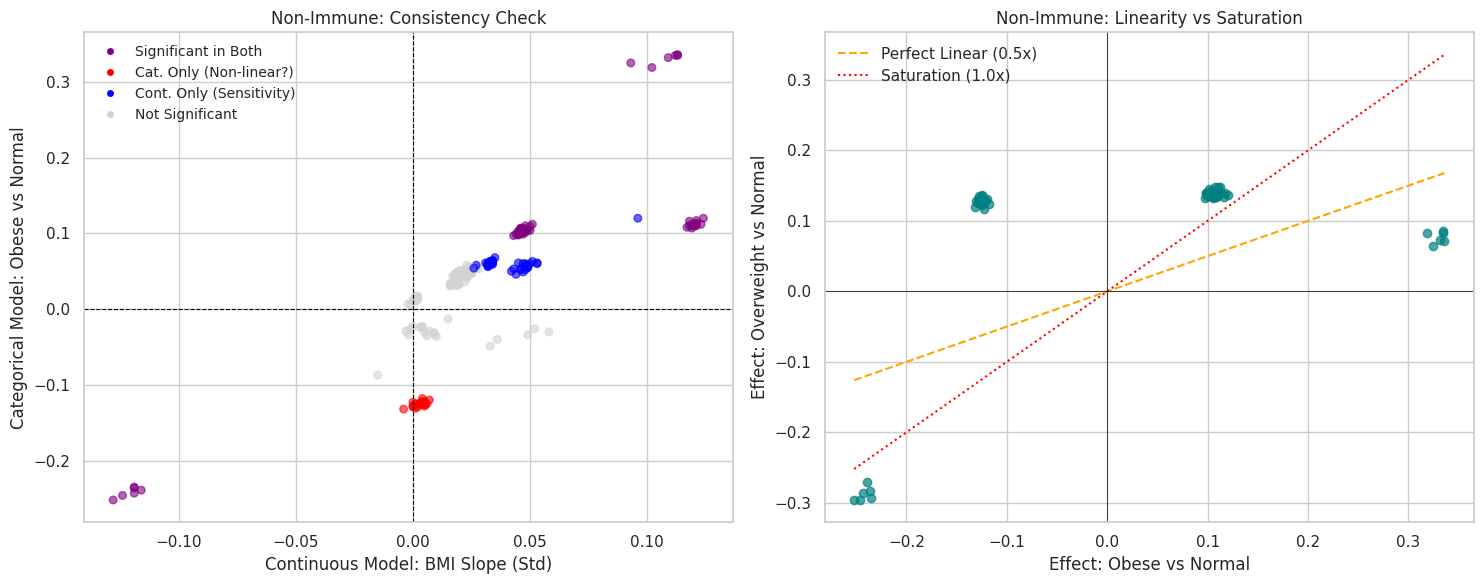

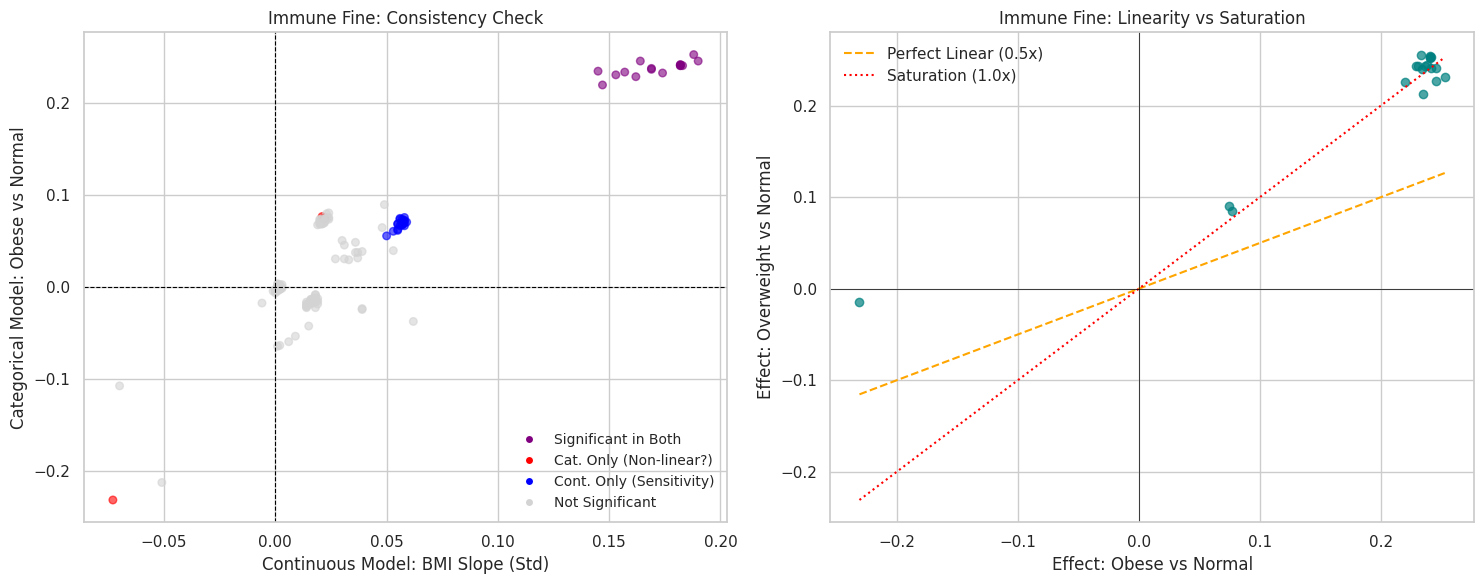

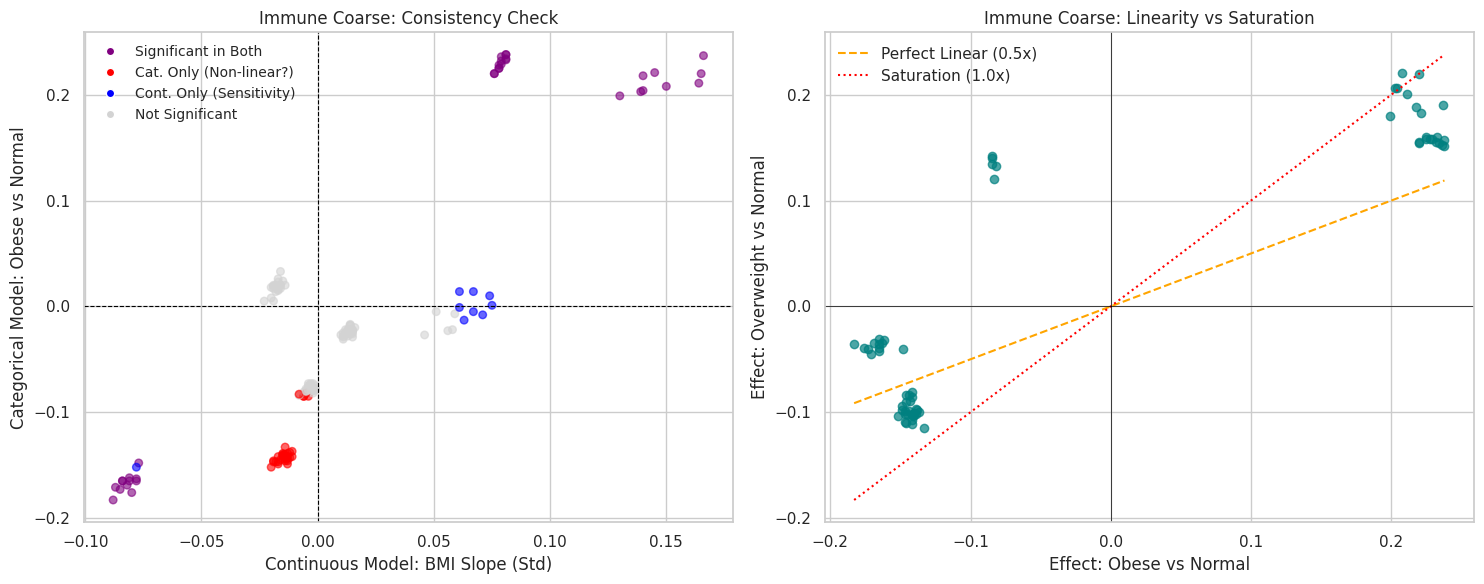

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D

# ==============================================================================
# CONFIGURATION
# ==============================================================================

# UPDATE THESE PATHS TO MATCH YOUR OUTPUT FOLDERS
BASE_DIR = "/content/drive/MyDrive/new_dysfunction"

# Define the pairs to compare
# Format: (Analysis Name, Categorical Folder Name, Continuous Folder Name)
COMPARISONS = [
    ("Non-Immune", "bayesian_hierarchical_3group_nonimmune", "bayesian_hierarchical_continuous_nonimmune"),
    ("Immune Fine", "bayesian_hierarchical_3group_immune_fine", "bayesian_hierarchical_continuous_immune_fine"),
    ("Immune Coarse", "bayesian_hierarchical_3group_immune_coarse", "bayesian_hierarchical_continuous_immune_coarse")
]

def load_and_merge(cat_path, cont_path):
    """Loads and merges the result CSVs from both models."""

    # Load Categorical Results
    df_cat = pd.read_csv(os.path.join(cat_path, "bayesian_results_3group.csv"))
    # Rename columns to avoid collision
    df_cat = df_cat.rename(columns={
        'obese_vs_normal_mean': 'cat_obese_mean',
        'obese_vs_normal_hdi_low': 'cat_obese_low',
        'obese_vs_normal_hdi_high': 'cat_obese_high',
        'overweight_vs_normal_mean': 'cat_overweight_mean',
        'overweight_vs_normal_hdi_low': 'cat_overweight_low',
        'overweight_vs_normal_hdi_high': 'cat_overweight_high'
    })

    # Determine significance in Categorical (HDI does not cross 0)
    df_cat['cat_sig'] = (df_cat['cat_obese_low'] > 0) | (df_cat['cat_obese_high'] < 0)

    # Load Continuous Results
    df_cont = pd.read_csv(os.path.join(cont_path, "bayesian_results_continuous.csv"))
    # Rename
    df_cont = df_cont.rename(columns={
        'bmi_slope_standardized_mean': 'cont_slope_mean',
        'bmi_slope_standardized_hdi_low': 'cont_slope_low',
        'bmi_slope_standardized_hdi_high': 'cont_slope_high'
    })

    # Determine significance in Continuous
    df_cont['cont_sig'] = (df_cont['cont_slope_low'] > 0) | (df_cont['cont_slope_high'] < 0)

    # Merge on feature and cell_type
    merged = pd.merge(
        df_cat[['feature', 'cell_type', 'cat_obese_mean', 'cat_overweight_mean', 'cat_sig', 'cat_obese_low', 'cat_obese_high']],
        df_cont[['feature', 'cell_type', 'cont_slope_mean', 'cont_sig', 'cont_slope_low', 'cont_slope_high']],
        on=['feature', 'cell_type'],
        how='inner'
    )

    return merged

def plot_global_consistency(df, title, ax):
    """Plot 1: Scatter of Slope vs Obese Effect"""

    # Color logic:
    # Gray: Not sig in either
    # Blue: Sig in Continuous only
    # Red: Sig in Categorical only
    # Purple: Sig in Both

    colors = []
    for _, row in df.iterrows():
        if row['cat_sig'] and row['cont_sig']:
            colors.append('purple') # Both
        elif row['cat_sig']:
            colors.append('red') # Cat only
        elif row['cont_sig']:
            colors.append('blue') # Cont only
        else:
            colors.append('lightgray')

    ax.scatter(df['cont_slope_mean'], df['cat_obese_mean'], c=colors, alpha=0.6, s=30)

    # Add diagonal lines (Visual guide for linearity)
    # If perfect linear, Obese Effect ~= Slope * (Difference in Z-score from Normal to Obese)
    # Roughly, Obese is usually +2 SDs away from Normal in BMI terms.
    # So we expect y = 2x approx. Let's just draw regression.

    # Axis lines
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

    ax.set_xlabel("Continuous Model: BMI Slope (Std)")
    ax.set_ylabel("Categorical Model: Obese vs Normal")
    ax.set_title(f"{title}: Consistency Check")

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', label='Significant in Both'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Cat. Only (Non-linear?)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Cont. Only (Sensitivity)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', label='Not Significant')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize='small')

def plot_linearity_check(df, title, ax):
    """Plot 2: Overweight vs Obese (Testing Saturation)"""

    # Filter for things significant in at least the Categorical model (Obese)
    # Otherwise we are just plotting noise
    subset = df[df['cat_sig']].copy()

    if len(subset) == 0:
        ax.text(0.5, 0.5, "No significant categorical features", ha='center')
        return

    ax.scatter(subset['cat_obese_mean'], subset['cat_overweight_mean'], alpha=0.7, color='teal')

    # Theoretical Linear Line: Overweight should be ~half of Obese impact
    # Assuming Overweight BMI ~ 27 and Obese BMI ~ 35 vs Normal ~ 22.
    # (27-22)/(35-22) = 5/13 ~= 0.4
    x_vals = np.linspace(subset['cat_obese_mean'].min(), subset['cat_obese_mean'].max(), 100)
    ax.plot(x_vals, x_vals * 0.5, color='orange', linestyle='--', label='Perfect Linear (0.5x)')
    ax.plot(x_vals, x_vals * 1.0, color='red', linestyle=':', label='Saturation (1.0x)')

    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)

    ax.set_xlabel("Effect: Obese vs Normal")
    ax.set_ylabel("Effect: Overweight vs Normal")
    ax.set_title(f"{title}: Linearity vs Saturation")
    ax.legend()

def run_comparison():
    for name, cat_dir, cont_dir in COMPARISONS:
        cat_full_path = os.path.join(BASE_DIR, cat_dir)
        cont_full_path = os.path.join(BASE_DIR, cont_dir)

        print(f"Processing {name}...")

        try:
            merged = load_and_merge(cat_full_path, cont_full_path)

            # Setup Plot
            fig, axes = plt.subplots(1, 2, figsize=(15, 6))

            # 1. Global Consistency
            plot_global_consistency(merged, name, axes[0])

            # 2. Linearity Check
            plot_linearity_check(merged, name, axes[1])

            plt.tight_layout()
            save_path = os.path.join(BASE_DIR, f"{name.replace(' ', '_')}_comparison.png")
            plt.savefig(save_path, dpi=300)
            print(f"Saved plot to {save_path}")

            # Calculate Agreement Stats
            both = len(merged[merged['cat_sig'] & merged['cont_sig']])
            cat_only = len(merged[merged['cat_sig'] & ~merged['cont_sig']])
            cont_only = len(merged[~merged['cat_sig'] & merged['cont_sig']])

            print(f"Stats for {name}:")
            print(f"  Agreed Significant: {both}")
            print(f"  Categorical Only (Potential Non-linear): {cat_only}")
            print(f"  Continuous Only (Potential Sensitivity): {cont_only}")
            print("-" * 30)

        except Exception as e:
            print(f"Skipping {name} (Data missing?): {e}")

if __name__ == "__main__":
    # Ensure seaborn style
    sns.set_theme(style="whitegrid")
    run_comparison()

# model comaprison venn


Processing Non-Immune...
  ✅ Saved overlap list to: /content/drive/MyDrive/new_dysfunction/model_comparison_overlap/Non-Immune_feature_overlap.csv

Processing Immune Fine...
  ✅ Saved overlap list to: /content/drive/MyDrive/new_dysfunction/model_comparison_overlap/Immune_Fine_feature_overlap.csv

Processing Immune Coarse...
  ✅ Saved overlap list to: /content/drive/MyDrive/new_dysfunction/model_comparison_overlap/Immune_Coarse_feature_overlap.csv

📊 Venn Diagram saved to (PNG): /content/drive/MyDrive/new_dysfunction/model_comparison_overlap/venn_diagram_comparison.png
📊 Venn Diagram saved to (SVG): /content/drive/MyDrive/new_dysfunction/model_comparison_overlap/venn_diagram_comparison.svg

SUMMARY TABLE:
     Analysis  Both  Categorical_Only  Continuous_Only  Total_Significant
   Non-Immune    83                60               21                164
  Immune Fine    37                69                0                106
Immune Coarse    35                71                7         

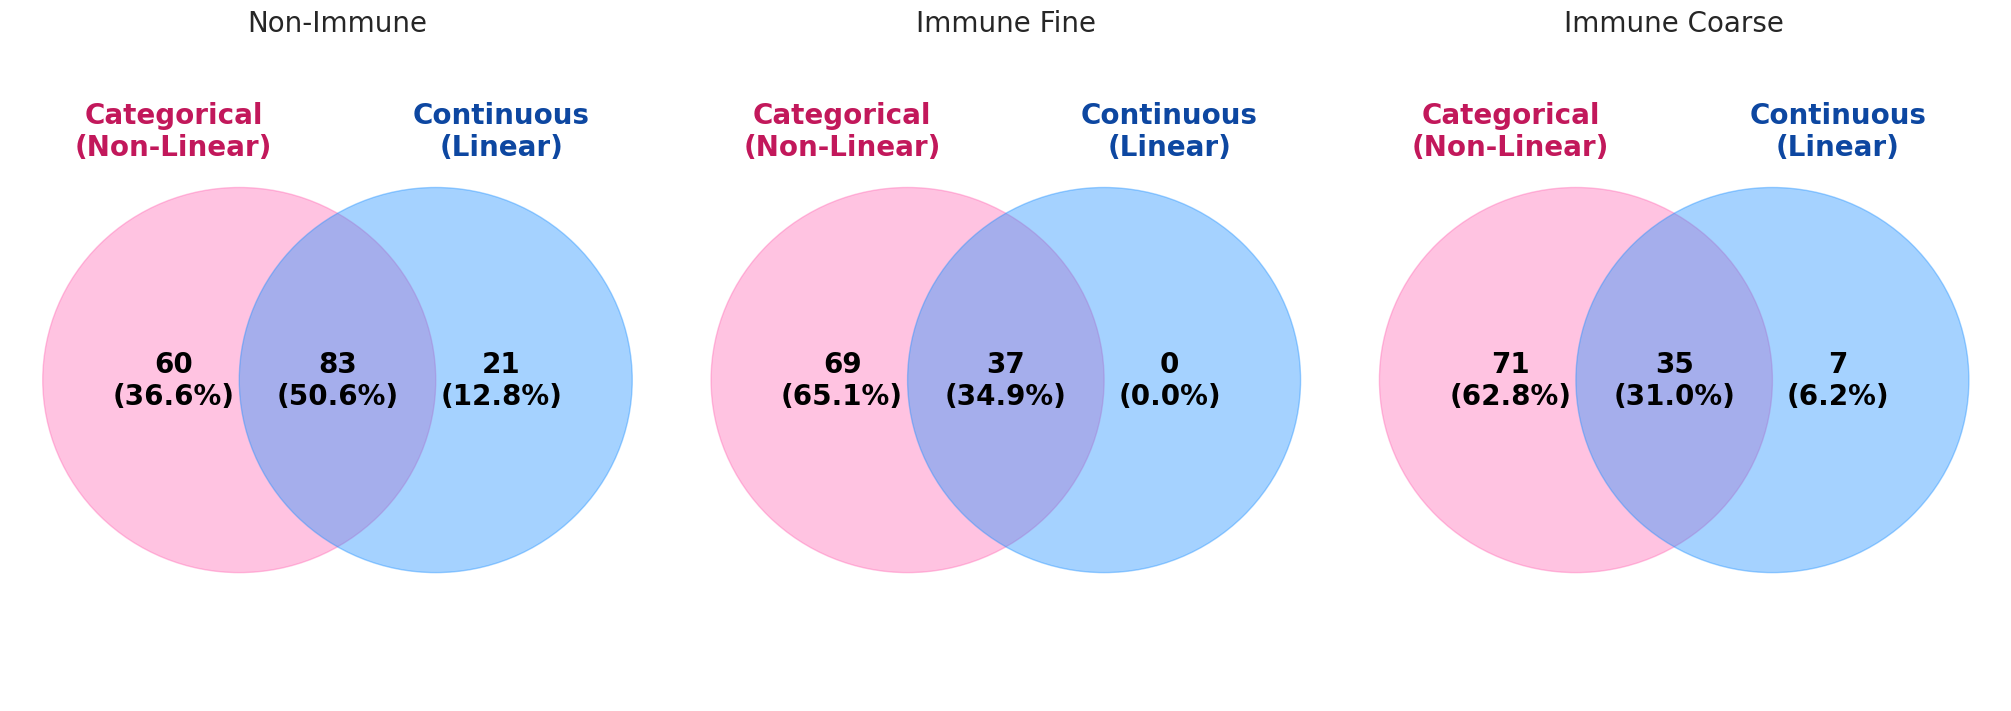

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Circle

# ==============================================================================
# CONFIGURATION
# ==============================================================================

BASE_DIR = "/content/drive/MyDrive/new_dysfunction"

# --- 🎨 VISUAL TUNABLES ---
# Colors (Hex codes or names)
COLOR_CAT = '#FF69B4'       # Pink (Categorical/Non-Linear)
COLOR_CONT = '#1E90FF'      # Blue (Continuous/Linear)
ALPHA = 0.4                 # Transparency (0.0 to 1.0)

# Text Sizes
FONT_SIZE_TITLE = 20        # Main title for each subplot
FONT_SIZE_LABEL = 20        # "Categorical" / "Continuous" labels
FONT_SIZE_COUNT = 20        # The big numbers inside circles
FONT_SIZE_PCT = 18          # The percentages inside circles

# Text Colors
TEXT_COLOR_CAT = '#C2185B'  # Darker Pink for label text
TEXT_COLOR_CONT = '#0D47A1' # Darker Blue for label text

# Layout
FIG_SIZE = (20, 7)          # Width, Height in inches
SPACING_W = 0.3             # Horizontal space between plots

# --- ANALYSIS PATHS ---
ANALYSES = [
    {
        "name": "Non-Immune",
        "cat_dir": "bayesian_hierarchical_3group_nonimmune",
        "cont_dir": "bayesian_hierarchical_continuous_nonimmune"
    },
    {
        "name": "Immune Fine",
        "cat_dir": "bayesian_hierarchical_3group_immune_fine",
        "cont_dir": "bayesian_hierarchical_continuous_immune_fine"
    },
    {
        "name": "Immune Coarse",
        "cat_dir": "bayesian_hierarchical_3group_immune_coarse",
        "cont_dir": "bayesian_hierarchical_continuous_immune_coarse"
    }
]

# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def load_data(cat_path, cont_path):
    """Loads and identifies significant features from both models."""

    # 1. Load Categorical Results
    try:
        df_cat = pd.read_csv(os.path.join(cat_path, "bayesian_results_3group.csv"))
    except FileNotFoundError:
        print(f"❌ Missing Categorical file: {cat_path}")
        return None, None, None

    # Categorical Significance Definition:
    # 95% HDI of 'Obese vs Normal' does NOT include 0
    # OR 'Overweight vs Normal' does NOT include 0
    df_cat['is_sig'] = (
        (df_cat['obese_vs_normal_hdi_low'] > 0) | (df_cat['obese_vs_normal_hdi_high'] < 0) |
        (df_cat['overweight_vs_normal_hdi_low'] > 0) | (df_cat['overweight_vs_normal_hdi_high'] < 0)
    )
    sig_cat_features = set(df_cat[df_cat['is_sig']]['feature'])

    # 2. Load Continuous Results
    try:
        df_cont = pd.read_csv(os.path.join(cont_path, "bayesian_results_continuous.csv"))
    except FileNotFoundError:
        print(f"❌ Missing Continuous file: {cont_path}")
        return None, None, None

    # Continuous Significance Definition:
    # 95% HDI of 'BMI Slope' does NOT include 0
    df_cont['is_sig'] = (df_cont['bmi_slope_standardized_hdi_low'] > 0) | \
                        (df_cont['bmi_slope_standardized_hdi_high'] < 0)
    sig_cont_features = set(df_cont[df_cont['is_sig']]['feature'])

    return sig_cat_features, sig_cont_features, df_cat

def draw_venn(ax, set_a, set_b, labels=("Categorical", "Continuous"), title="Venn Diagram"):
    """Draws a manually scaled Venn diagram using global visual settings."""

    # Calculate sizes
    only_a = len(set_a - set_b)
    only_b = len(set_b - set_a)
    intersection = len(set_a & set_b)
    total_sig = only_a + only_b + intersection

    if total_sig == 0:
        ax.text(0.5, 0.5, "No Significant Features", ha='center', va='center', fontsize=FONT_SIZE_LABEL)
        ax.set_title(title, fontsize=FONT_SIZE_TITLE, pad=20)
        ax.axis('off')
        return

    # Circle positions and radius
    # Left circle
    c1 = Circle((0.35, 0.5), 0.3, color=COLOR_CAT, alpha=ALPHA)
    # Right circle
    c2 = Circle((0.65, 0.5), 0.3, color=COLOR_CONT, alpha=ALPHA)

    ax.add_patch(c1)
    ax.add_patch(c2)

    # --- TEXT ANNOTATIONS ---

    # Helper to format count and percent
    def fmt_text(count, total):
        pct = count / total * 100
        return f"{count}\n({pct:.1f}%)"

    # 1. Only Categorical (Left)
    ax.text(0.25, 0.5,
            fmt_text(only_a, total_sig),
            ha='center', va='center',
            fontsize=FONT_SIZE_COUNT, fontweight='bold', color='black')

    # 2. Intersection (Middle)
    ax.text(0.5, 0.5,
            fmt_text(intersection, total_sig),
            ha='center', va='center',
            fontsize=FONT_SIZE_COUNT, fontweight='bold', color='black')

    # 3. Only Continuous (Right)
    ax.text(0.75, 0.5,
            fmt_text(only_b, total_sig),
            ha='center', va='center',
            fontsize=FONT_SIZE_COUNT, fontweight='bold', color='black')

    # --- LABELS ---
    # Left Label
    ax.text(0.25, 0.85,
            f"{labels[0]}\n(Non-Linear)",
            ha='center',
            fontsize=FONT_SIZE_LABEL,
            color=TEXT_COLOR_CAT, fontweight='bold')

    # Right Label
    ax.text(0.75, 0.85,
            f"{labels[1]}\n(Linear)",
            ha='center',
            fontsize=FONT_SIZE_LABEL,
            color=TEXT_COLOR_CONT, fontweight='bold')

    # Plot settings
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=FONT_SIZE_TITLE, pad=20)
    ax.axis('off')

# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def main():
    # Prepare Plot
    fig, axes = plt.subplots(1, 3, figsize=FIG_SIZE)
    plt.subplots_adjust(wspace=SPACING_W)

    output_base = os.path.join(BASE_DIR, "model_comparison_overlap")
    os.makedirs(output_base, exist_ok=True)

    summary_data = []

    for i, analysis in enumerate(ANALYSES):
        print(f"\nProcessing {analysis['name']}...")

        cat_path = os.path.join(BASE_DIR, analysis['cat_dir'])
        cont_path = os.path.join(BASE_DIR, analysis['cont_dir'])

        # Get sets of significant features
        set_cat, set_cont, _ = load_data(cat_path, cont_path)

        if set_cat is None:
            # Handle missing data gracefully by hiding the axis
            axes[i].axis('off')
            axes[i].set_title(f"{analysis['name']} (Missing Data)", fontsize=FONT_SIZE_TITLE)
            continue

        # Draw Venn
        draw_venn(axes[i], set_cat, set_cont, title=analysis['name'])

        # Save lists of discordant features
        only_cat = list(set_cat - set_cont)
        only_cont = list(set_cont - set_cat)
        intersection = list(set_cat & set_cont)

        # Save CSVs for the user to inspect
        overlap_df = pd.DataFrame({
            "Feature": intersection + only_cat + only_cont,
            "Group": ["Both"]*len(intersection) + ["Categorical_Only"]*len(only_cat) + ["Continuous_Only"]*len(only_cont),
            "Analysis": analysis['name']
        })

        csv_path = os.path.join(output_base, f"{analysis['name'].replace(' ', '_')}_feature_overlap.csv")
        overlap_df.to_csv(csv_path, index=False)
        print(f"  ✅ Saved overlap list to: {csv_path}")

        summary_data.append({
            "Analysis": analysis['name'],
            "Both": len(intersection),
            "Categorical_Only": len(only_cat),
            "Continuous_Only": len(only_cont),
            "Total_Significant": len(set_cat | set_cont)
        })

    # Save Plot - PNG
    png_path = os.path.join(output_base, "venn_diagram_comparison.png")
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f"\n📊 Venn Diagram saved to (PNG): {png_path}")

    # Save Plot - SVG
    svg_path = os.path.join(output_base, "venn_diagram_comparison.svg")
    plt.savefig(svg_path, format='svg', bbox_inches='tight')
    print(f"📊 Venn Diagram saved to (SVG): {svg_path}")

    # Print simple summary table
    summary_df = pd.DataFrame(summary_data)
    print("\nSUMMARY TABLE:")
    print(summary_df.to_string(index=False))

if __name__ == "__main__":
    main()